<a href="https://colab.research.google.com/github/trsantanarural/predicao-falhas-tarefas/blob/main/notebooks/03_analise_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Análise exploratória

**Entrada:** `saida/base_modelagem.parquet` (notebook 02)
**Saídas:** figuras em `figuras/`

Conjuntos: treino = dias 1 a 19, validação = dias 20 a 23, teste = dias 24 a 29. As estatísticas por classe usam apenas o treino e a validação (dias 1 a 23), para não usar o teste na análise.

## 1. Configuração do ambiente

In [24]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
import numpy as np
import pandas as pd

# Pasta de trabalho no Google Drive (dados intermediários e figuras)
BASE = '/content/drive/MyDrive/artigo_predicao'
for d in ['ev_parts', 'uso_parts', 'saida', 'figuras']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

KEY = ['job_id', 'task_index']   # identificador de uma tarefa no trace
FRAC = 10                        # amostra: jobs com job_id % 10 == 0 (~10% dos jobs)

import matplotlib.pyplot as plt
import seaborn as sns
FIG = f'{BASE}/figuras'

base = pd.read_parquet(f'{BASE}/saida/base_modelagem.parquet')
base['conjunto'] = np.where(base.dia >= 24, 'teste', np.where(base.dia >= 20, 'validação', 'treino'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Estilo das figuras

In [25]:
import matplotlib.pyplot as plt
import numpy as np
AZUL, LARANJA = '#2a78d6', '#eb6834'
TXT, TXT2, GRADE = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'font.size': 10, 'axes.edgecolor': TXT2, 'axes.labelcolor': TXT, 'xtick.color': TXT2,
    'ytick.color': TXT2, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRADE, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.bbox': 'tight'})

## 2. Tamanho e taxa de falha por conjunto

In [26]:
base.groupby('conjunto').falha.agg(['size', 'sum', 'mean'])

,size,sum,mean
conjunto,,,
teste,134744,9064,0.067268
treino,475204,30145,0.063436
validação,114401,6836,0.059755


## 3. Taxa de falha por dia do trace
Faixas sombreadas indicam os períodos de validação (dias 20 a 23) e de teste (dias 24 a 29); a linha tracejada é a taxa média dos dias 1 a 23.

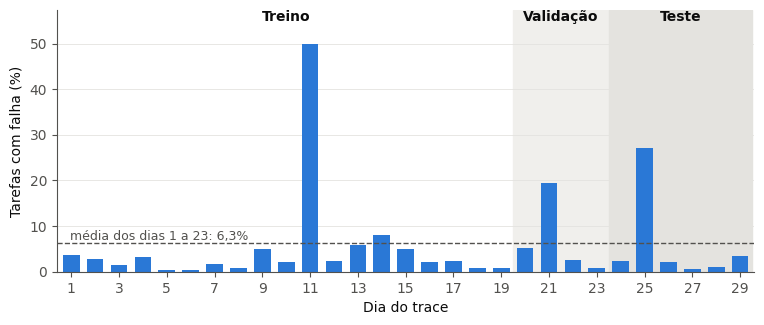

In [27]:
d = base.groupby('dia').falha.mean() * 100
media_trein = base[base.dia <= 23].falha.mean() * 100
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.axvspan(19.5, 23.5, color='#f0efec', zorder=0)
ax.axvspan(23.5, 29.5, color='#e4e3df', zorder=0)
ax.bar(d.index, d.values, width=0.7, color=AZUL, zorder=2)
ax.axhline(media_trein, ls='--', lw=1, color=TXT2, zorder=3)
ax.text(0.8, media_trein, f' média dos dias 1 a 23: {media_trein:.1f}%'.replace('.', ','), va='bottom', fontsize=9, color=TXT2)
ymax = d.max() * 1.15
for x, rot in [(10, 'Treino'), (21.5, 'Validação'), (26.5, 'Teste')]:
    ax.text(x, ymax, rot, ha='center', va='top', fontsize=10, color=TXT, fontweight='bold')
ax.set_ylim(0, ymax); ax.set_xlim(0.4, 29.6)
ax.set_xticks(range(1, 30, 2)); ax.grid(axis='x', visible=False)
ax.set_xlabel('Dia do trace'); ax.set_ylabel('Tarefas com falha (%)')
fig.savefig(f'{FIG}/taxa_falha_dia.png', dpi=200)
plt.show()

## 4. Concentração das falhas por job

In [28]:
fj = base[base.falha == 1].groupby('job_id').size().sort_values(ascending=False)
print('jobs com falha:', len(fj), '| os 10 maiores concentram', round(fj.head(10).sum() / fj.sum(), 3), 'das falhas')
fj.head(10)

jobs com falha: 796 | os 10 maiores concentram 0.756 das falhas


,0
job_id,
6337545460,19579
6449919400,6655
6418746280,3115
6414778640,1391
6420299240,884
6316758500,833
6357618720,645
6304918650,612
6361680850,566


## 5. Valores ausentes de CPI e MAI e sua relação com a falha

In [29]:
for c in ['cpi', 'mai']:
    print(c, base.groupby(base[c].isna()).falha.agg(['size', 'mean']).to_dict())

cpi {'size': {False: 598532, True: 125817}, 'mean': {False: 0.07520232836339577, True: 0.008218285287361803}}
mai {'size': {False: 581146, True: 143203}, 'mean': {False: 0.07385063305950657, True: 0.02183613471784809}}


## 6. Medianas dos atributos por classe (dias 1 a 23)

In [30]:
FEAT = ['priority','scheduling_class','cpu_req','ram_req','disk_req','cpu_rate','canonical_mem',
        'assigned_mem','unmapped_cache','total_cache','disk_space','cpi','mai','sampled_cpu',
        'max_mem','max_cpu','tempo_obs','n_janelas']
tr = base[base.dia <= 23]
tr.groupby('falha')[FEAT].median().T

falha,0,1
priority,4.0,1.0
scheduling_class,0.0,0.0
cpu_req,0.03024,0.0125
ram_req,0.0318,0.0159
disk_req,0.00027,0.000404
cpu_rate,0.014913,0.003692
canonical_mem,0.004233,0.004104
assigned_mem,0.005298,0.005983
unmapped_cache,0.000172,0.001159
total_cache,0.000306,0.001319


## 7. Comparação dos atributos entre as classes
### 7.1 Razão entre medianas (falha ÷ conclusão)
Barras à direita de 1× indicam atributos com mediana maior nas tarefas que falharam; à esquerda, menor. Escala logarítmica, para que 2× e 0,5× fiquem à mesma distância de 1×.

Fora do gráfico (mediana zero em alguma classe): ['Classe de escalonamento']


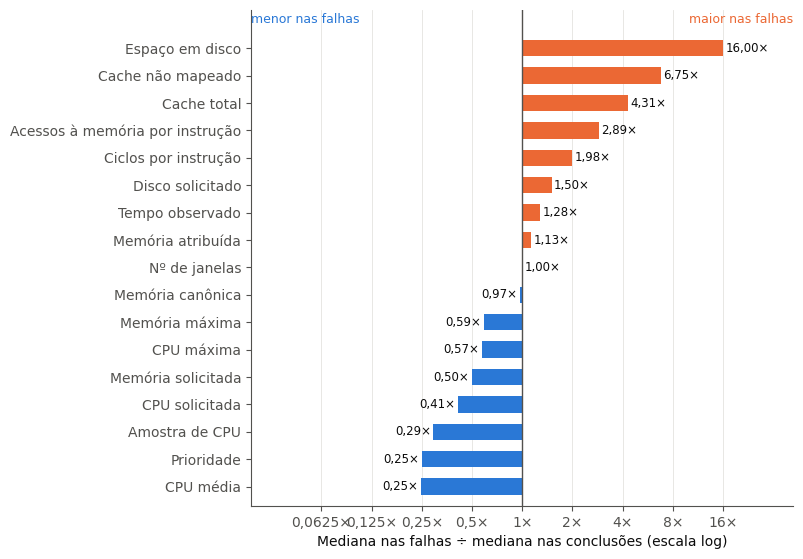

In [33]:
NOMES = {'priority':'Prioridade','scheduling_class':'Classe de escalonamento','cpu_req':'CPU solicitada',
         'ram_req':'Memória solicitada','disk_req':'Disco solicitado','cpu_rate':'CPU média',
         'canonical_mem':'Memória canônica','assigned_mem':'Memória atribuída',
         'unmapped_cache':'Cache não mapeado','total_cache':'Cache total','disk_space':'Espaço em disco',
         'cpi':'Ciclos por instrução','mai':'Acessos à memória por instrução','sampled_cpu':'Amostra de CPU',
         'max_mem':'Memória máxima','max_cpu':'CPU máxima','tempo_obs':'Tempo observado',
         'n_janelas':'Nº de janelas'}
med = tr.groupby('falha')[list(NOMES)].median().T
med.columns = ['FINISH', 'FAIL']
validos = med[(med.FINISH > 0) & (med.FAIL > 0)].copy()
print('Fora do gráfico (mediana zero em alguma classe):', [NOMES[c] for c in med.index.difference(validos.index)])
validos['razao'] = validos.FAIL / validos.FINISH
validos = validos.sort_values('razao')
fig, ax = plt.subplots(figsize=(7, 0.32 * len(validos) + 1))
y = np.arange(len(validos)); r = validos.razao.values.astype(float)
ax.barh(y, np.log2(r), height=0.6, color=np.where(r >= 1, LARANJA, AZUL), zorder=2)
ax.axvline(0, color=TXT2, lw=1)
for yi, ri in zip(y, r):
    ax.text(np.log2(ri) + (0.05 if ri >= 1 else -0.05), yi, f'{ri:.2f}×'.replace('.', ','), va='center',
            ha='left' if ri >= 1 else 'right', fontsize=8.5, color=TXT)
ax.set_yticks(y); ax.set_yticklabels([NOMES[c] for c in validos.index])
lim = np.abs(np.log2(r)).max() * 1.35
ax.set_xlim(-lim, lim); ax.set_ylim(-0.7, len(validos) + 0.4); ax.grid(axis='y', visible=False)
tk = [t for t in [-4, -3, -2, -1, 0, 1, 2, 3, 4] if abs(t) <= lim]
ax.set_xticks(tk); ax.set_xticklabels([f'{2.0**t:g}×'.replace('.', ',') for t in tk])
ax.set_xlabel('Mediana nas falhas ÷ mediana nas conclusões (escala log)')
ax.text(-lim, len(validos) - 0.2, 'menor nas falhas', color=AZUL, fontsize=9, va='bottom')
ax.text(lim, len(validos) - 0.2, 'maior nas falhas', color=LARANJA, fontsize=9, va='bottom', ha='right')
fig.savefig(f'{FIG}/razao_medianas.png', dpi=200)
plt.show()

### 7.2 Distribuições por classe (escala log)
Caixas com mediana e quartis; valores extremos omitidos. A escala logarítmica evita que as caudas longas comprimam as caixas.

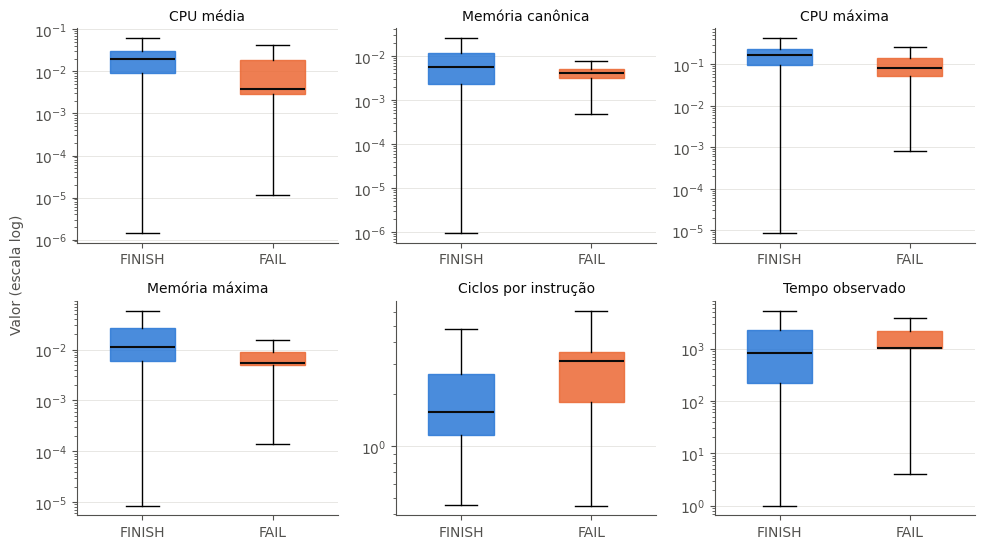

In [34]:
sel = ['cpu_rate', 'canonical_mem', 'max_cpu', 'max_mem', 'cpi', 'tempo_obs']
am = tr.sample(min(200_000, len(tr)), random_state=42)
fig, axs = plt.subplots(2, 3, figsize=(10, 5.6))
for ax, c in zip(axs.flat, sel):
    dados = [am.loc[am.falha == k, c].dropna() for k in (0, 1)]
    dados = [v[v > 0] for v in dados]
    bp = ax.boxplot(dados, widths=0.5, showfliers=False, patch_artist=True,
                    medianprops=dict(color=TXT, lw=1.5))
    for patch, cor in zip(bp['boxes'], (AZUL, LARANJA)):
        patch.set_facecolor(cor); patch.set_alpha(0.85); patch.set_edgecolor(cor)
    ax.set_yscale('log'); ax.set_title(NOMES[c], fontsize=10, color=TXT)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['FINISH', 'FAIL']); ax.grid(axis='x', visible=False)
fig.supylabel('Valor (escala log)', fontsize=10, color=TXT2)
fig.tight_layout()
fig.savefig(f'{FIG}/atributos_por_classe.png', dpi=200)
plt.show()